# 📊 Final Project Delivery: Data Warehouse & Real-time Kafka Pipeline
**Course:** ETL (G51)  
**Program:** Data Engineering and Artificial Intelligence  

This notebook contains the complete monolithic implementation of the data warehouse and real-time streaming pipeline.

### Architecture Overview
1. **Data Extraction (Sources):** Extracts data from a local dataset (WHO Household Air Pollution CSV) and two APIs (OpenAQ API and REST Countries API).
2. **Orchestration (Airflow DAG):** Automates the extract, transform, validate, and load tasks.
3. **Data Quality (Great Expectations):** Validates staging data schema and values before ingestion into the data warehouse.
4. **Data Modeling (DuckDB/SQLite Star Schema):** Builds a relational dimensional model containing `dim_location`, `dim_date`, and `fact_air_quality`.
5. **Streaming (Kafka KRaft Broker):** Streams facts from the warehouse to a Kafka topic in real time.
6. **Analytics (Analytical Dashboard):** Connects to the SQLite warehouse to build Plotly dashboards.
7. **Real-time Consumption (Kafka Consumer & Operational Dashboard):** Consumes Kafka messages in real time and renders a live, updating dashboard in Colab.


## collab env

In [3]:
!PYTHON_VERSION="$(python -c 'import sys; print(f"{sys.version_info.major}.{sys.version_info.minor}")')" && \
pip install \
  "numpy==1.26.4" \
  "apache-airflow==2.11.2" \
  "great-expectations>=1.0.0" \
  "confluent-kafka" \
  "plotly" \
  "scikit-learn" \
  "matplotlib" \
  "seaborn" \
  --constraint "https://raw.githubusercontent.com/apache/airflow/constraints-2.11.2/constraints-${PYTHON_VERSION}.txt"

In [4]:
# runMe (COLLAB ONLY)
from google.colab import drive
from google.colab import userdata
import shutil
import os

# Mount Google Drive
drive.mount('/content/drive')

# Source and destination paths
src = "/content/drive/My Drive/2026/etl/datasets/who-household-air-pollution.csv"
dst = '/content/data/raw/who-household-air-pollution.csv'

# Make sure destination folder exists
os.makedirs(os.path.dirname(dst), exist_ok=True)

# Copy the file
shutil.copy(src, dst)

print(f"Copied to: {dst}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied to: /content/data/raw/who-household-air-pollution.csv


In [5]:
import os

# 1. Instalar Airflow y la última versión de Great Expectations
print("Instalando dependencias (puede tardar 1 minuto)...")
#!PYTHON_VERSION="$(python -c 'import sys; print(f"{sys.version_info.major}.{sys.version_info.minor}")')" && \
#pip install "apache-airflow==2.11.2" "great-expectations>=1.0.0" pandas --constraint "https://raw.githubusercontent.com/apache/airflow/constraints-2.11.2/constraints-${PYTHON_VERSION}.txt" > /dev/null 2>&1
!PYTHON_VERSION="$(python -c 'import sys; print(f"{sys.version_info.major}.{sys.version_info.minor}")')" && \
pip install "apache-airflow==2.11.2" "great-expectations>=1.0.0" --constraint "https://raw.githubusercontent.com/apache/airflow/constraints-2.11.2/constraints-${PYTHON_VERSION}.txt" > /dev/null 2>&1
# deleted pandas

# 2. Configuración de entorno
os.environ['AIRFLOW_HOME'] = '/content/airflow'
os.environ['AIRFLOW__CORE__LOAD_EXAMPLES'] = 'False'
os.environ['AIRFLOW__WEBSERVER__WEB_SERVER_PORT'] = '8081'

# 3. Inicializar Airflow
!airflow db migrate > /dev/null 2>&1
!mkdir -p /content/airflow/dags

print("✅ Entorno de Airflow y Great Expectations listo.")

Instalando dependencias (puede tardar 1 minuto)...
✅ Entorno de Airflow y Great Expectations listo.


## 2. Setting up Apache Kafka (KRaft mode)
We configure a standalone Kafka broker inside Colab without needing ZooKeeper (using Kafka Raft metadata mode).


In [6]:
# SAAAR, DO NOT RADEEM THE CARD
#!pip install -q confluent-kafka plotly pandas scikit-learn matplotlib seaborn

import time
import os

# 1. Download and extract Kafka
!wget -q https://archive.apache.org/dist/kafka/3.7.0/kafka_2.13-3.7.0.tgz
!tar -xzf kafka_2.13-3.7.0.tgz

# 2. Configure KRaft
!uuid=$(./kafka_2.13-3.7.0/bin/kafka-storage.sh random-uuid) && ./kafka_2.13-3.7.0/bin/kafka-storage.sh format -t $uuid -c ./kafka_2.13-3.7.0/config/kraft/server.properties

# 3. Start Kafka in the background
!./kafka_2.13-3.7.0/bin/kafka-server-start.sh -daemon ./kafka_2.13-3.7.0/config/kraft/server.properties

print("Starting Local Kafka Broker...")
time.sleep(10) # Give it time to fully start
print("Kafka is ready!")

Exception in thread "main" java.lang.RuntimeException: Invalid cluster.id in: /tmp/kraft-combined-logs/meta.properties. Expected XkXtFge4RDqWd2chlnvHOw, but read Vu7tw8b_RhmtQWrj7X9fyg
	at org.apache.kafka.metadata.properties.MetaPropertiesEnsemble.verify(MetaPropertiesEnsemble.java:516)
	at kafka.tools.StorageTool$.formatCommand(StorageTool.scala:433)
	at kafka.tools.StorageTool$.main(StorageTool.scala:95)
	at kafka.tools.StorageTool.main(StorageTool.scala)
Starting Local Kafka Broker...
Kafka is ready!


## 3. Airflow DAG Definition
We create and save our Airflow DAG, which will extract data from the sources, clean/merge it, run data quality audits using Great Expectations, load it into the Star Schema tables, and publish real-time updates to the Kafka Broker.


In [53]:
%%writefile /content/airflow/dags/etl_air_quality.py
from datetime import datetime, timedelta
from airflow import DAG
from airflow.operators.python import PythonOperator, BranchPythonOperator
from airflow.operators.bash import BashOperator
from airflow.operators.empty import EmptyOperator

from confluent_kafka import Producer

import sqlite3
import pandas as pd
import requests
import json
import time

default_args = {
    'owner': 'data_engineer',
    'depends_on_past': False,
    'retries': 0,
}

with DAG(
    'final_air_quality_warehouse_pipeline',
    default_args=default_args,
    schedule_interval=timedelta(minutes=5),
    start_date=datetime(2025, 1, 1),
    catchup=False,
) as dag:

    def extract_and_transform():
        print("Ingesting WHO Air Pollution CSV...")
        df_who = pd.DataFrame()
        try:
            raw_csv_path = '/content/data/raw/who-household-air-pollution.csv'
            df_who = pd.read_csv(raw_csv_path)
            # Filter specifically for Clean Fuels indicator
            df_who = df_who[df_who['IndicatorCode'] == 'PHE_HHAIR_PROP_POP_CLEAN_FUELS'].copy()
            df_who.rename(columns={'SpatialDimValueCode': 'iso_alpha3', 'FactValueNumeric': 'clean_fuel_access'}, inplace=True)
            df_who = df_who[['iso_alpha3', 'clean_fuel_access', 'Period']].dropna()
            df_who = df_who.sort_values('Period').groupby('iso_alpha3').tail(1)
        except Exception as e:
            print(f"CSV Ingestion issue: {e}")

        print("Querying OpenAQ API with location enrichment...")

        from datetime import datetime, timezone

        df_aq = pd.DataFrame()

        API_KEY = "this is going on github there's no way i leave the api key here lmao"

        HEADERS = {
            "X-API-Key": API_KEY
        }

        LATEST_URL = "https://api.openaq.org/v3/parameters/2/latest"

        LOCATION_URL_BASE = "https://api.openaq.org/v3/locations"

        location_cache = {}

        records = []

        try:

            # -------------------------------------------------
            # STEP 1 — FETCH LATEST PM2.5 READINGS
            # -------------------------------------------------

            response = requests.get(
                LATEST_URL,
                headers=HEADERS,
                params={"limit": 1000},
                timeout=30
            )

            print(f"OpenAQ latest status: {response.status_code}")

            response.raise_for_status()

            payload = response.json()

            results = payload.get("results", [])

            print(f"Measurements received: {len(results)}")

            # -------------------------------------------------
            # STEP 2 — COLLECT UNIQUE LOCATION IDs
            # -------------------------------------------------

            unique_location_ids = set()

            for item in results:

                loc_id = item.get("locationsId")

                if loc_id:
                    unique_location_ids.add(loc_id)

            print(f"Unique locations found: {len(unique_location_ids)}")

            # -------------------------------------------------
            # STEP 3 — RESOLVE LOCATIONS TO COUNTRIES
            # -------------------------------------------------

            for loc_id in unique_location_ids:

                try:

                    location_response = requests.get(
                        f"{LOCATION_URL_BASE}/{loc_id}",
                        headers=HEADERS,
                        timeout=20
                    )

                    if location_response.status_code != 200:
                        continue

                    loc_payload = location_response.json()

                    loc_results = loc_payload.get("results", [])

                    if not loc_results:
                        continue

                    loc_info = loc_results[0]

                    country_code = (
                        loc_info.get("country", {})
                        .get("code")
                    )

                    if country_code:

                        location_cache[loc_id] = country_code.upper()

                except Exception as loc_error:

                    print(f"Location enrichment failed for {loc_id}: {loc_error}")

                    continue

                # avoid hammering API
                time.sleep(0.05)

            print(f"Resolved countries: {len(location_cache)}")

            # -------------------------------------------------
            # STEP 4 — BUILD COUNTRY-LEVEL RECORDS
            # -------------------------------------------------

            for item in results:

                try:

                    loc_id = item.get("locationsId")

                    country_code = location_cache.get(loc_id)

                    value = item.get("value")

                    timestamp = (
                        item.get("datetime", {})
                        .get("utc")
                    )

                    if not country_code:
                        continue

                    if value is None:
                        continue

                    if not timestamp:
                        continue

                    # reject impossible readings
                    if value < 0 or value > 500:
                        continue

                    records.append({
                        "country_iso": country_code,
                        "pm25_value": float(value),
                        "timestamp": timestamp
                    })

                except Exception as row_error:

                    print(f"Measurement parse failure: {row_error}")

                    continue

            print(f"Valid enriched measurements: {len(records)}")

            # -------------------------------------------------
            # STEP 5 — COUNTRY AGGREGATION
            # -------------------------------------------------

            if records:

                df_aq = pd.DataFrame(records)

                # stabilize country codes
                df_aq["country_iso"] = (
                    df_aq["country_iso"]
                    .astype(str)
                    .str.upper()
                    .str.strip()
                )

                # aggregate using median
                df_aq = (
                    df_aq.groupby("country_iso", as_index=False)
                    .agg({
                        "pm25_value": "median"
                    })
                )

                print(
                    f"Successfully aggregated "
                    f"{len(df_aq)} countries."
                )

                print(df_aq.head())

                # optional debug artifact
                df_aq.to_csv(
                    "/content/debug/openaq_country_aggregates.csv",
                    index=False
                )

        except Exception as e:

            print(f"OpenAQ extraction failed: {e}")

        # -------------------------------------------------
        # FALLBACK ONLY IF ABSOLUTELY NECESSARY
        # -------------------------------------------------

        if df_aq.empty:

            print("OpenAQ returned no usable data. Applying fallback dataset.")

            import random

            mock_data = [
                {'country_iso': 'EC', 'pm25_value': random.uniform(8.0, 18.0)},
                {'country_iso': 'PE', 'pm25_value': random.uniform(25.0, 45.0)},
                {'country_iso': 'BR', 'pm25_value': random.uniform(12.0, 22.0)},
                {'country_iso': 'AR', 'pm25_value': random.uniform(9.0, 19.0)},
                {'country_iso': 'MX', 'pm25_value': random.uniform(18.0, 32.0)},
                {'country_iso': 'CO', 'pm25_value': random.uniform(10.0, 20.0)},
                {'country_iso': 'CL', 'pm25_value': random.uniform(15.0, 35.0)}
            ]

            df_aq = pd.DataFrame(mock_data)

        print("Querying REST Countries API...")
        df_countries = pd.DataFrame()
        countries_url = "https://restcountries.com/v3.1/all?fields=cca3,cca2,name,region,population"
        try:
            response_countries = requests.get(countries_url, timeout=10)
            if response_countries.status_code == 200:
                c_data = response_countries.json()
                df_countries = pd.DataFrame([{
                    'iso_alpha3': c.get('cca3'),
                    'iso_alpha2': c.get('cca2'),
                    'country_name': c.get('name', {}).get('common'),
                    'region': c.get('region'),
                    'population': c.get('population', 0)
                } for c in c_data])
        except Exception as e:
            print(f"REST Countries request failed: {e}")

        print("Merging and cleansing data for staging...")
        if not df_countries.empty:
            if not df_who.empty:
                df_merged = pd.merge(df_countries, df_who, on='iso_alpha3', how='left')
            else:
                df_merged = df_countries.copy()
                df_merged['clean_fuel_access'] = 50.0

            if not df_aq.empty:

                df_merged = pd.merge(
                    df_merged,
                    df_aq,
                    left_on='iso_alpha2',
                    right_on='country_iso',
                    how='left'
                )

            else:

                df_merged['pm25_value'] = None

            # regional median imputation
            regional_pm25 = (
                df_merged.groupby('region')['pm25_value']
                .transform('median')
            )

            df_merged['pm25_value'] = (
                df_merged['pm25_value']
                .fillna(regional_pm25)
                .fillna(12.0)
            )

            # stabilize remaining columns
            df_merged['clean_fuel_access'] = (
                df_merged['clean_fuel_access']
                .fillna(50.0)
            )

            df_merged['population'] = (
                pd.to_numeric(
                    df_merged['population'],
                    errors='coerce'
                )
                .fillna(0)
            )

            df_merged['clean_fuel_access'] = df_merged['clean_fuel_access'].fillna(50.0)

            df_merged.to_csv('/content/staging_air_quality.csv', index=False)

            # more debugging
            import os

            os.makedirs('/content/debug', exist_ok=True)

            print("Countries from OpenAQ:")

            if not df_aq.empty and 'country_iso' in df_aq.columns:

                pd.DataFrame({
                    'openaq_country': sorted(
                        df_aq['country_iso'].unique()
                    )
                }).to_csv(
                    '/content/debug/openaq_country_codes.csv',
                    index=False
                )

                print("Saved OpenAQ country codes debug file.")

            else:
                print("df_aq empty or missing country_iso column.")

    extract_transform_task = PythonOperator(
        task_id='extract_and_transform',
        python_callable=extract_and_transform,
    )

    def validate_data_quality():
        import great_expectations as gx
        import great_expectations.expectations as gxe

        try:
            print("Loading staging data for Great Expectations validation...")
            df = pd.read_csv('/content/staging_air_quality.csv')
            context = gx.get_context()

            # Config Expectation Suite
            try:
                suite = gx.ExpectationSuite(name="air_quality_contract")
                suite.add_expectation(gxe.ExpectColumnValuesToNotBeNull(column="iso_alpha3"))
                suite.add_expectation(gxe.ExpectColumnValuesToBeBetween(column="population", min_value=0))
                suite.add_expectation(
                    gxe.ExpectColumnValuesToBeBetween(
                        column="pm25_value",
                        min_value=0,
                        max_value=500
                    )
                )
                context.suites.add(suite)
            except Exception:
                suite = context.suites.get(name="air_quality_contract")

            # Setup Data Source
            try:
                source = context.data_sources.add_pandas("airflow_ds")
            except Exception:
                source = context.data_sources.get("airflow_ds")

            try:
                asset = source.add_dataframe_asset("air_asset")
            except Exception:
                asset = source.get_asset("air_asset")

            try:
                batch_def = asset.add_batch_definition_whole_dataframe("daily_batch")
            except Exception:
                batch_def = asset.get_batch_definition("daily_batch")

            # Setup Validation
            try:
                validation = gx.ValidationDefinition(data=batch_def, suite=suite, name="air_audit")
                context.validation_definitions.add(validation)
            except Exception:
                validation = context.validation_definitions.get("air_audit")

            # Setup Checkpoint
            try:
                ckpt = gx.Checkpoint(name="air_checkpoint", validation_definitions=[validation])
                context.checkpoints.add(ckpt)
            except Exception:
                ckpt = context.checkpoints.get("air_checkpoint")

            # Run Audit
            results = ckpt.run(batch_parameters={"dataframe": df})

            if results.success:
                print("✅ Data Quality contract passed successfully!")
                return 'load_data_warehouse'
            else:
                print("❌ Data Quality contract validation FAILED.")
                return 'ruta_mover_a_cuarentena'

        except Exception as e:
            print(f"Exception during validation: {e}")
            return 'ruta_mover_a_cuarentena'

    validate_task = BranchPythonOperator(
        task_id='validate_with_gx',
        python_callable=validate_data_quality,
    )

    def load_sqlite_dw():
        print("Connecting to SQLite Warehouse database...")
        conn = sqlite3.connect('/content/air_quality_warehouse.db')
        cursor = conn.cursor()

        cursor.execute('DROP TABLE IF EXISTS dim_location')
        cursor.execute('CREATE TABLE dim_location (iso_alpha3 TEXT PRIMARY KEY, country_name TEXT, region TEXT, population INTEGER)')

        cursor.execute('DROP TABLE IF EXISTS fact_air_quality')
        cursor.execute('CREATE TABLE fact_air_quality (iso_alpha3 TEXT, pm25_value REAL, clean_fuel_access REAL, timestamp DATETIME DEFAULT CURRENT_TIMESTAMP)')

        df = pd.read_csv('/content/staging_air_quality.csv')

        # Load dim_location
        dim_loc = df[['iso_alpha3', 'country_name', 'region', 'population']].drop_duplicates()
        dim_loc.to_sql('dim_location', conn, if_exists='append', index=False)

        # Load fact table
        fact_aq = df[['iso_alpha3', 'pm25_value', 'clean_fuel_access']]
        fact_aq.to_sql('fact_air_quality', conn, if_exists='append', index=False)

        conn.commit()
        conn.close()
        print("✅ Data loaded successfully into Dimensional model tables.")

    load_dw_task = PythonOperator(
        task_id='load_data_warehouse',
        python_callable=load_sqlite_dw,
    )

    def stream_metrics_to_kafka():
        from confluent_kafka import Producer

        print("Querying SQLite fact table to stream events...")
        conn = sqlite3.connect('/content/air_quality_warehouse.db')
        query = """
            SELECT f.iso_alpha3, l.country_name, f.pm25_value, f.clean_fuel_access, f.timestamp
            FROM fact_air_quality f
            JOIN dim_location l ON f.iso_alpha3 = l.iso_alpha3
        """
        df_facts = pd.read_sql_query(query, conn)
        conn.close()

        # Connect to local Kafka Broker
        try:
            #producer = Producer(
            #    bootstrap_servers=['localhost:9092'],
            #    value_serializer=lambda v: json.dumps(v).encode('utf-8')
            #)
            producer = Producer({
                'bootstrap.servers': 'localhost:9092'
            })

            topic = 'air_quality_metrics'
            print(f"Streaming {len(df_facts)} records to topic '{topic}'...")

            # Stream with a slight delay
            for _, row in df_facts.iterrows():
                payload = {
                    'iso_alpha3': row['iso_alpha3'],
                    'country_name': row['country_name'],
                    'pm25_value': float(row['pm25_value']),
                    'clean_fuel_access': float(row['clean_fuel_access']),
                    'timestamp': str(row['timestamp'])
                }
                #producer.send(topic, value=payload)
                producer.produce(
                    topic,
                    value=json.dumps(payload).encode('utf-8')
                )
                time.sleep(0.05) # delay to simulate real-time
            producer.flush()
            print("✅ All events streamed successfully to Kafka broker.")
        except Exception as e:
            print(f"Failed to stream to Kafka: {e}")

    stream_kafka_task = PythonOperator(
        task_id='stream_to_kafka',
        python_callable=stream_metrics_to_kafka,
    )

    mover_cuarentena = BashOperator(
        task_id='ruta_mover_a_cuarentena',
        bash_command='echo "[ ❌ ] Data issues found. Moving staging data to quarantine directory..." && mv /content/staging_air_quality.csv /content/data/quarantine/quarantine_out.csv',
    )

    enviar_alerta = BashOperator(
        task_id='enviar_alerta',
        bash_command='echo "⚠️ PIPELINE NOTIFICATION: Staged air quality batch failed validation rules."',
    )

    fin = EmptyOperator(task_id='fin_proceso', trigger_rule='none_failed_min_one_success')

    # DAG Dependency graph
    extract_transform_task >> validate_task
    validate_task >> load_dw_task >> stream_kafka_task >> fin
    validate_task >> mover_cuarentena >> enviar_alerta >> fin


Overwriting /content/airflow/dags/etl_air_quality.py


## 4. Launching Airflow Standalone Server & Secure Tunnel
We set up an admin user, start the Airflow webserver in standalone mode, and create a Cloudflare tunnel to access the Airflow UI externally.


In [58]:
import os, time, urllib.request, re

os.system("fuser -k 8081/tcp > /dev/null 2>&1")
os.system("pkill -9 -f cloudflared > /dev/null 2>&1")

print("1/3 Configuring Admin User...")
os.system("airflow users create -u admin -p admin -f Data -l Engineer -r Admin -e admin@example.com > /dev/null 2>&1")

print("2/3 Starting Airflow Orchestrator (~30 seconds)...")
get_ipython().system_raw('airflow standalone > /content/airflow.log 2>&1 &')

ready = False
for _ in range(30):
    try:
        if urllib.request.urlopen('http://localhost:8081').getcode() == 200:
            ready = True
            break
    except:
        time.sleep(2)

if not ready:
    print("❌ Error starting server. Check logs.")
else:
    print("✅ Webserver active.\n3/3 Initializing Tunnel...")
    os.system("wget -q -nc https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O /content/cloudflared")
    os.system("chmod +x /content/cloudflared")
    get_ipython().system_raw('/content/cloudflared tunnel --url http://localhost:8081 > /content/tunnel.log 2>&1 &')
    time.sleep(6)

    tunnel_logs = open('/content/tunnel.log', 'r').read()
    urls = re.findall(r'https://[a-zA-Z0-9-]+\.trycloudflare\.com', tunnel_logs)

    if urls:
        print("\n" + "═"*55)
        print("🚀 AIRFLOW URL: " + urls[0])
        print("👤 User: admin  |  🔑 Pass: admin")
        print("═"*55)
    else:
        print("❌ Tunnel generation failed.")


1/3 Configuring Admin User...
2/3 Starting Airflow Orchestrator (~30 seconds)...
✅ Webserver active.
3/3 Initializing Tunnel...

═══════════════════════════════════════════════════════
🚀 AIRFLOW URL: https://infants-shoe-attractions-benz.trycloudflare.com
👤 User: admin  |  🔑 Pass: admin
═══════════════════════════════════════════════════════


## 5. Analytical Dashboard (Static Analytical Process)
Here, we query the SQL-compliant Star Schema warehouse directly and use Plotly to render business intelligence reports.
*(Note: Please ensure the DAG has run at least once in Airflow UI before executing this cell to populate the database).*


In [61]:
import sqlite3
import pandas as pd
import plotly.express as px
import numpy as np
import os

db_path = '/content/air_quality_warehouse.db'

if os.path.exists(db_path):

    conn = sqlite3.connect(db_path)

    try:

        query = '''
            SELECT
                l.iso_alpha3,
                l.country_name,
                l.region,
                l.population,
                f.pm25_value,
                f.clean_fuel_access,
                f.timestamp
            FROM dim_location l
            JOIN fact_air_quality f
                ON l.iso_alpha3 = f.iso_alpha3
        '''

        df_dw = pd.read_sql_query(query, conn)

        # ----------------------------------------
        # CLEANING
        # ----------------------------------------

        df_dw = df_dw.drop_duplicates()

        df_dw['population'] = pd.to_numeric(
            df_dw['population'],
            errors='coerce'
        )

        df_dw['pm25_value'] = pd.to_numeric(
            df_dw['pm25_value'],
            errors='coerce'
        )

        df_dw['clean_fuel_access'] = pd.to_numeric(
            df_dw['clean_fuel_access'],
            errors='coerce'
        )

        # remove impossible rows
        df_dw = df_dw[
            (df_dw['pm25_value'] >= 0) &
            (df_dw['clean_fuel_access'] >= 0)
        ]

        # log population for better scaling
        df_dw['log_population'] = np.log10(
            df_dw['population'].replace(0, np.nan)
        )

        print(df_dw.head())

        # ========================================
        # CHART 1 — CLEAN FUEL ACCESS
        # ========================================

        fig1 = px.choropleth(
            df_dw,
            locations="iso_alpha3",
            color="clean_fuel_access",
            hover_name="country_name",
            hover_data=[
                "region",
                "population",
                "pm25_value"
            ],
            color_continuous_scale="Viridis",
            title="Global Clean Fuel Access (%)",
        )

        fig1.update_layout(
            height=600
        )

        fig1.show()

        # ========================================
        # CHART 2 — PM2.5 LEVELS
        # ========================================

        fig2 = px.choropleth(
            df_dw,
            locations="iso_alpha3",
            color="pm25_value",
            hover_name="country_name",
            hover_data=[
                "region",
                "population",
                "clean_fuel_access"
            ],
            color_continuous_scale="Reds",
            title="Global PM2.5 Concentration Levels",
        )

        fig2.update_layout(
            height=600
        )

        fig2.show()

        # ========================================
        # CHART 3 — CORRELATION
        # ========================================

        scatter_df = df_dw.dropna(
            subset=[
                'pm25_value',
                'clean_fuel_access',
                'log_population'
            ]
        )

        fig3 = px.scatter(
            scatter_df,
            x="clean_fuel_access",
            y="pm25_value",
            color="region",
            size="log_population",
            hover_name="country_name",
            hover_data=[
                "population"
            ],
            size_max=35,
            title=(
                "PM2.5 vs Clean Fuel Access "
                "(Bubble size = Log Population)"
            ),
            labels={
                "clean_fuel_access": "Clean Fuel Access (%)",
                "pm25_value": "PM2.5"
            }
        )

        fig3.update_layout(
            height=700
        )

        fig3.show()

    except Exception as e:

        print(f"Error querying DW: {e}")

    finally:

        conn.close()

else:

    print(
        "Warehouse database not populated yet. "
        "Run your DAG in Airflow."
    )

  iso_alpha3 country_name    region  population  pm25_value  \
0        AIA     Anguilla  Americas       16010   27.120000   
1        GTM    Guatemala  Americas    18079810   27.120000   
2        GMB       Gambia    Africa     2422712    5.524833   
3        MEX       Mexico  Americas   130575786   17.940000   
4        MWI       Malawi    Africa    20734262    5.524833   

   clean_fuel_access            timestamp  log_population  
0               50.0  2026-05-25 06:58:40        4.204391  
1               69.8  2026-05-25 06:58:40        7.257194  
2                0.1  2026-05-25 06:58:40        6.384302  
3               85.1  2026-05-25 06:58:40        8.115863  
4                5.1  2026-05-25 06:58:40        7.316689  


## 6. Real-time Consumer & Live Operational Dashboard
We instantiate a Kafka consumer to capture the real-time streamed metrics from the event topic and display live updates on an interactive chart.


### graph

do note that this one, while less needy (not reliant on external widgets) displays every streamed entry and refreshes on update, which gives me a bit of a photophobic seizure and thus is left as a small wonder for the reader whether it acually works.

KeyboardInterrupt: 

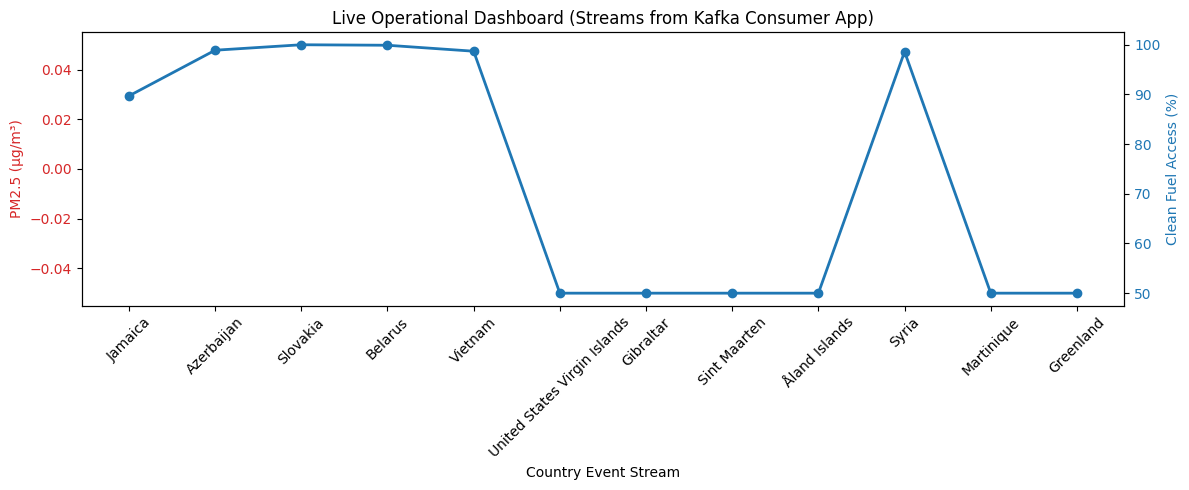

In [68]:
from confluent_kafka import Consumer
import json
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
import time

config_consumer = {
    'bootstrap.servers': 'localhost:9092',
    'group.id': 'realtime-group-dashboard',
    'auto.offset.reset': 'earliest'
}

try:
    consumer = Consumer(config_consumer)

    # Subscribe to topic
    consumer.subscribe(['air_quality_metrics'])

    print("Listening to real-time events streamed via Kafka topic 'air_quality_metrics'...")

    countries = []
    pm25_vals = []
    fuels = []

    while True:
        msg = consumer.poll(1.0)

        if msg is None:
            continue

        if msg.error():
            print(f"Consumer error: {msg.error()}")
            continue

        # Deserialize message manually
        val = json.loads(msg.value().decode('utf-8'))

        countries.append(val['country_name'])
        pm25_vals.append(val['pm25_value'])
        fuels.append(val['clean_fuel_access'])

        # Display rolling live dual-axis plot
        clear_output(wait=True)

        fig, ax1 = plt.subplots(figsize=(12, 5))

        color = 'tab:red'
        ax1.set_xlabel('Country Event Stream')
        ax1.set_ylabel('PM2.5 (µg/m³)', color=color)

        ax1.bar(
            countries[-12:],
            pm25_vals[-12:],
            color=color,
            alpha=0.6
        )

        ax1.tick_params(axis='y', labelcolor=color)
        plt.xticks(rotation=45)

        ax2 = ax1.twinx()

        color = 'tab:blue'
        ax2.set_ylabel('Clean Fuel Access (%)', color=color)

        ax2.plot(
            countries[-12:],
            fuels[-12:],
            color=color,
            marker='o',
            linewidth=2
        )

        ax2.tick_params(axis='y', labelcolor=color)

        plt.title("Live Operational Dashboard (Streams from Kafka Consumer App)")
        fig.tight_layout()

        display(fig)
        plt.close(fig)

        time.sleep(0.1)

except Exception as e:
    print(f"Kafka consumer connection or execution issue: {e}")

finally:
    consumer.close()

### another graph

#### run for collab

In [65]:
from google.colab import output
output.enable_custom_widget_manager()

Support for third party widgets will remain active for the duration of the session. To disable support:

In [ ]:
from google.colab import output
output.disable_custom_widget_manager()

In [66]:
from confluent_kafka import Consumer
import json
import pandas as pd
import plotly.graph_objects as go
from IPython.display import display
import time

config_consumer = {
    'bootstrap.servers': 'localhost:9092',
    'group.id': 'realtime-group-dashboard',
    'auto.offset.reset': 'earliest'
}

try:

    consumer = Consumer(config_consumer)

    consumer.subscribe(['air_quality_metrics'])

    print(
        "Listening to Kafka topic "
        "'air_quality_metrics'..."
    )

    countries = []
    pm25_vals = []
    fuels = []

    # ----------------------------------------
    # INITIAL FIGURE
    # ----------------------------------------

    fig = go.FigureWidget()

    # PM2.5 bars
    bar_trace = go.Bar(
        x=[],
        y=[],
        name='PM2.5',
        opacity=0.7
    )

    # Fuel line
    line_trace = go.Scatter(
        x=[],
        y=[],
        mode='lines+markers',
        name='Clean Fuel Access',
        yaxis='y2'
    )

    fig.add_trace(bar_trace)
    fig.add_trace(line_trace)

    fig.update_layout(
        title="Live Air Quality Stream",
        xaxis=dict(
            title='Country Event Stream'
        ),
        yaxis=dict(
            title='PM2.5 (µg/m³)'
        ),
        yaxis2=dict(
            title='Clean Fuel Access (%)',
            overlaying='y',
            side='right',
            range=[0, 100]
        ),
        height=600,
        width=1100,
        template='plotly_dark'
    )

    display(fig)

    # ----------------------------------------
    # STREAM LOOP
    # ----------------------------------------

    while True:

        msg = consumer.poll(1.0)

        if msg is None:
            continue

        if msg.error():
            print(f"Consumer error: {msg.error()}")
            continue

        val = json.loads(
            msg.value().decode('utf-8')
        )

        country = val.get('country_name')
        pm25 = val.get('pm25_value')
        fuel = val.get('clean_fuel_access')

        # skip garbage rows
        if not country:
            continue

        if pm25 is None or fuel is None:
            continue

        # keep kafka arrival order
        countries.append(country)
        pm25_vals.append(pm25)
        fuels.append(fuel)

        # rolling window
        countries = countries[-15:]
        pm25_vals = pm25_vals[-15:]
        fuels = fuels[-15:]

        # ----------------------------------------
        # LIVE UPDATE
        # ----------------------------------------

        with fig.batch_update():

            fig.data[0].x = countries
            fig.data[0].y = pm25_vals

            fig.data[1].x = countries
            fig.data[1].y = fuels

        time.sleep(0.1)

except Exception as e:

    print(
        f"Kafka consumer execution issue: {e}"
    )

finally:

    consumer.close()

Listening to Kafka topic 'air_quality_metrics'...


FigureWidget({
    'data': [{'name': 'PM2.5',
              'opacity': 0.7,
              'type': 'bar',
              'uid': '70e82916-1ed2-4e77-9b35-057fa6311c97',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'name': 'Clean Fuel Access',
              'type': 'scatter',
              'uid': '105e0408-ff0c-47b9-b91d-c8e9c2f1711d',
              'x': [],
              'y': [],
              'yaxis': 'y2'}],
    'layout': {'height': 600,
               'template': '...',
               'title': {'text': 'Live Air Quality Stream'},
               'width': 1100,
               'xaxis': {'title': {'text': 'Country Event Stream'}},
               'yaxis': {'title': {'text': 'PM2.5 (µg/m³)'}},
               'yaxis2': {'overlaying': 'y',
                          'range': [0, 100],
                          'side': 'right',
                          'title': {'text': 'Clean Fuel Access (%)'}}}
})

KeyboardInterrupt: 

- - -

# legacy

tests and graphs while testing pipeline and plotting. due for cleanup but i grew emotionally attached to my mistakes

In [59]:
import sqlite3
import pandas as pd
import plotly.express as px

db_path = '/content/air_quality_warehouse.db'

if os.path.exists(db_path):
    conn = sqlite3.connect(db_path)

    try:
        query = '''
            SELECT l.country_name, l.region, l.population,
                   f.pm25_value, f.clean_fuel_access
            FROM dim_location l
            JOIN fact_air_quality f ON l.iso_alpha3 = f.iso_alpha3
        '''
        df_dw = pd.read_sql_query(query, conn)

        # Chart 1: Global choropleth of Clean Fuel access
        fig1 = px.choropleth(
            df_dw,
            locations="country_name", locationmode="country names",
            color="clean_fuel_access", hover_name="country_name",
            hover_data=["population", "pm25_value"],
            color_continuous_scale="Viridis",
            title="Clean Fuel Access by Country (Batch DW Analytical)"
        )
        fig1.show()

        # Chart 2: Correlation Scatter plot
        fig2 = px.scatter(
            df_dw[df_dw['population'] > 0], x="population", y="clean_fuel_access",
            color="region", hover_name="country_name",
            log_x=True, size="pm25_value", size_max=40,
            title="Correlation: Clean Fuel Access vs Log-Population (Bubble size represents PM2.5 levels)"
        )
        fig2.show()

    except Exception as e:
        print(f"Error querying DW: {e}")
    finally:
        conn.close()
else:
    print("Warehouse database not populated yet. Run your DAG in Airflow.")


In [40]:
import sqlite3
import pandas as pd
import plotly.express as px

db_path = '/content/air_quality_warehouse.db'

if os.path.exists(db_path):
    conn = sqlite3.connect(db_path)

    try:
        query = '''
            SELECT l.country_name, l.region, l.population,
                   f.pm25_value, f.clean_fuel_access
            FROM dim_location l
            JOIN fact_air_quality f ON l.iso_alpha3 = f.iso_alpha3
        '''
        df_dw = pd.read_sql_query(query, conn)

        # Chart 1: Global choropleth of Clean Fuel access
        fig11 = px.choropleth(
            df_dw,
            locations="country_name", locationmode="country names",
            color="clean_fuel_access", hover_name="country_name",
            hover_data=["population", "pm25_value"],
            color_continuous_scale="Viridis",
            title="Clean Fuel Access by Country (Batch DW Analytical)"
        )
        fig11.show()

        # Chart 2: Correlation Scatter plot
        fig22 = px.scatter(
            df_dw[df_dw['population'] > 0], x="population", y="clean_fuel_access",
            color="region", hover_name="country_name",
            log_x=True, size="pm25_value", size_max=40,
            title="Correlation: Clean Fuel Access vs Log-Population (Bubble size represents PM2.5 levels)"
        )
        fig22.show()

    except Exception as e:
        print(f"Error querying DW: {e}")
    finally:
        conn.close()
else:
    print("Warehouse database not populated yet. Run your DAG in Airflow.")


Error querying DW: 
    Invalid element(s) received for the 'size' property of scatter.marker
        Invalid elements include: [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]

    The 'size' property is a number and may be specified as:
      - An int or float in the interval [0, inf]
      - A tuple, list, or one-dimensional numpy array of the above


## tetsts

In [13]:
import requests
# import pandas as pd
from datetime import datetime, timedelta, timezone

BASE_URL = "https://api.openaq.org/v3/measurements"

date_to = datetime.now(timezone.utc)
date_from = date_to - timedelta(hours=24)

params = {
    "parameter_id": 2,  # PM2.5
    "date_from": date_from.isoformat(),
    "date_to": date_to.isoformat(),
    "limit": 10,
    "page": 1
}

response = requests.get(BASE_URL, params=params, timeout=20)

print("STATUS:", response.status_code)

data = response.json()

print("\nTOP-LEVEL KEYS:")
print(data.keys())

results = data.get("results", [])

print(f"\nTOTAL RESULTS RETURNED: {len(results)}")

if results:

    df = pd.json_normalize(results)

    cols = [
        'country.code',
        'value',
        'unit',
        'datetime.utc',
        'location.name'
    ]

    existing_cols = [c for c in cols if c in df.columns]

    print("\nSAMPLE DATA:")
    print(df[existing_cols].head(10))

else:
    print("\nNo results returned.")

STATUS: 401

TOP-LEVEL KEYS:
dict_keys(['message'])

TOTAL RESULTS RETURNED: 0

No results returned.


In [14]:
import requests
from google.colab import userdata

# Read API key from Colab secrets
api_key = userdata.get('openaq_api_key')

print("KEY FOUND:", bool(api_key))

headers = {
    "X-API-Key": api_key
}

url = "https://api.openaq.org/v3/locations?limit=5"

response = requests.get(
    url,
    headers=headers,
    timeout=20
)

print("STATUS:", response.status_code)

try:
    print(response.json())
except Exception:
    print(response.text)

KEY FOUND: True
STATUS: 200
{'meta': {'name': 'openaq-api', 'website': '/', 'page': 1, 'limit': 5, 'found': '>5'}, 'results': [{'id': 3, 'name': 'NMA - Nima', 'locality': None, 'timezone': 'Africa/Accra', 'country': {'id': 152, 'code': 'GH', 'name': 'Ghana'}, 'owner': {'id': 4, 'name': 'Unknown Governmental Organization'}, 'provider': {'id': 209, 'name': 'Dr. Raphael E. Arku and Colleagues'}, 'isMobile': False, 'isMonitor': True, 'instruments': [{'id': 2, 'name': 'Government Monitor'}], 'sensors': [{'id': 6, 'name': 'pm10 µg/m³', 'parameter': {'id': 1, 'name': 'pm10', 'units': 'µg/m³', 'displayName': 'PM10'}}, {'id': 5, 'name': 'pm25 µg/m³', 'parameter': {'id': 2, 'name': 'pm25', 'units': 'µg/m³', 'displayName': 'PM2.5'}}], 'coordinates': {'latitude': 5.58389, 'longitude': -0.19968}, 'licenses': None, 'bounds': [-0.19968, 5.58389, -0.19968, 5.58389], 'distance': None, 'datetimeFirst': None, 'datetimeLast': None}, {'id': 4, 'name': 'NMT - Nima', 'locality': None, 'timezone': 'Africa/Acc

In [50]:
import requests
import pandas as pd
import json
from datetime import datetime, timedelta, timezone

API_KEY = userdata.get('openaq_api_key')

BASE_URL = "https://api.openaq.org/v3/measurements"

date_to = datetime.now(timezone.utc)
date_from = date_to - timedelta(hours=24)

params = {
    "parameter_id": 2,  # PM2.5
    "date_from": date_from.isoformat(),
    "date_to": date_to.isoformat(),
    "limit": 5,
    "page": 1
}

headers = {
    "X-API-Key": API_KEY
}

response = requests.get(
    BASE_URL,
    headers=headers,
    params=params,
    timeout=20
)

print("STATUS:", response.status_code)

payload = response.json()

print("\nTOP LEVEL KEYS:")
print(payload.keys())

results = payload.get("results", [])

print("\nTOTAL RESULTS:", len(results))

if results:

    print("\nFIRST RESULT:")
    print(json.dumps(results[0], indent=2))

    parsed = []

    for item in results:

        try:

            country = item.get("country", {}).get("code")
            value = item.get("value")

            # try several timestamp formats
            timestamp = None

            if item.get("datetime"):
                timestamp = item.get("datetime", {}).get("utc")

            elif item.get("date"):
                timestamp = item.get("date", {}).get("utc")

            parsed.append({
                "country": country,
                "value": value,
                "timestamp": timestamp
            })

        except Exception as e:
            print("ROW ERROR:", e)

    df = pd.DataFrame(parsed)

    print("\nPARSED DATAFRAME:")
    print(df.head())

    print("\nNULL COUNTS:")
    print(df.isnull().sum())

else:
    print("No results returned.")

STATUS: 404

TOP LEVEL KEYS:
dict_keys(['detail'])

TOTAL RESULTS: 0
No results returned.


In [51]:
import requests
from google.colab import userdata


headers = {
    "X-API-Key": API_KEY
}

url = "https://api.openaq.org/v3/parameters/2/latest"

response = requests.get(
    url,
    headers=headers,
    timeout=20
)

print("STATUS:", response.status_code)

try:
    data = response.json()

    print(data.keys())

    results = data.get("results", [])

    print("RESULT COUNT:", len(results))

    if results:
        print(results[0])

except Exception as e:
    print(e)

STATUS: 200
dict_keys(['meta', 'results'])
RESULT COUNT: 100
{'datetime': {'utc': '2026-05-25T04:00:00Z', 'local': '2026-05-25T13:00:00+09:00'}, 'value': 14.0, 'coordinates': {'latitude': 35.21815, 'longitude': 128.57425}, 'sensorsId': 8539597, 'locationsId': 2622686}


In [52]:
import requests
import json


headers = {
    "X-API-Key": API_KEY
}

location_id = 2622686

url = f"https://api.openaq.org/v3/locations/{location_id}"

response = requests.get(
    url,
    headers=headers,
    timeout=20
)

print("STATUS:", response.status_code)

data = response.json()

print(json.dumps(data, indent=2)[:4000])

STATUS: 200
{
  "meta": {
    "name": "openaq-api",
    "website": "/",
    "page": 1,
    "limit": 100,
    "found": 1
  },
  "results": [
    {
      "id": 2622686,
      "name": "\ud68c\uc6d0\ub3d9",
      "locality": " ",
      "timezone": "Asia/Seoul",
      "country": {
        "id": 25,
        "code": "KR",
        "name": "Republic of Korea"
      },
      "owner": {
        "id": 4,
        "name": "Unknown Governmental Organization"
      },
      "provider": {
        "id": 69,
        "name": "Korea Air Ministry of Environment"
      },
      "isMobile": false,
      "isMonitor": true,
      "instruments": [
        {
          "id": 2,
          "name": "Government Monitor"
        }
      ],
      "sensors": [
        {
          "id": 8534096,
          "name": "co ppm",
          "parameter": {
            "id": 8,
            "name": "co",
            "units": "ppm",
            "displayName": "CO"
          }
        },
        {
          "id": 8536505,
          "n

In [55]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('/content/air_quality_warehouse.db')

df = pd.read_sql_query("""
SELECT *
FROM fact_air_quality
ORDER BY timestamp DESC
LIMIT 20
""", conn)

conn.close()

print(df)

   iso_alpha3  pm25_value  clean_fuel_access            timestamp
0         AIA   18.545000              50.00  2026-05-25 06:18:51
1         GTM   18.545000              69.80  2026-05-25 06:18:51
2         GMB    8.086667               0.10  2026-05-25 06:18:51
3         MEX   14.690000              85.10  2026-05-25 06:18:51
4         MWI    8.086667               5.10  2026-05-25 06:18:51
5         PCN    5.900000              50.00  2026-05-25 06:18:51
6         ARG   18.545000              98.20  2026-05-25 06:18:51
7         GUM    5.900000              50.00  2026-05-25 06:18:51
8         BGR    7.000000              50.00  2026-05-25 06:18:51
9         DMA   18.545000              86.20  2026-05-25 06:18:51
10        GBR    5.100000             100.00  2026-05-25 06:18:51
11        FSM    5.900000              31.60  2026-05-25 06:18:51
12        PSE   24.480000              50.00  2026-05-25 06:18:51
13        CUW   18.545000              50.00  2026-05-25 06:18:51
14        